Dataset source: https://www.kaggle.com/datasets/laotse/credit-risk-dataset

# STEP 1: LOAD THE CREDIT RISK DATASET

In [36]:

# Import pandas
import pandas as pd

# Read the CSV file
df = pd.read_csv("data_credit_risk.csv")

# Display the first 5 rows
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## About Dataset
Detailed data description of Credit Risk dataset:
```
Feature Name	Description
person_age	Age
person_income	Annual Income
person_home_ownership	Home ownership
person_emp_length	Employment length (in years)
loan_intent	Loan intent
loan_grade	Loan grade
loan_amnt	Loan amount
loan_int_rate	Interest rate
loan_status	Loan status (0 is non default 1 is default)
loan_percent_income	Percent income
cb_person_default_on_file	Historical default
cb_preson_cred_hist_length	Credit history length

# EDA

In [2]:
# Check the shape of the dataset

print("Shape of dataset:", df.shape)

Shape of dataset: (32581, 12)


In [3]:
# Display column names

print(df.columns.tolist())

['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
# Summary statistics for numerical columns

df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
# Summary for categorical columns

df.describe(include='object')

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


In [37]:
# Check for missing values

print("missing value:\n", df.isnull().sum())

missing value:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


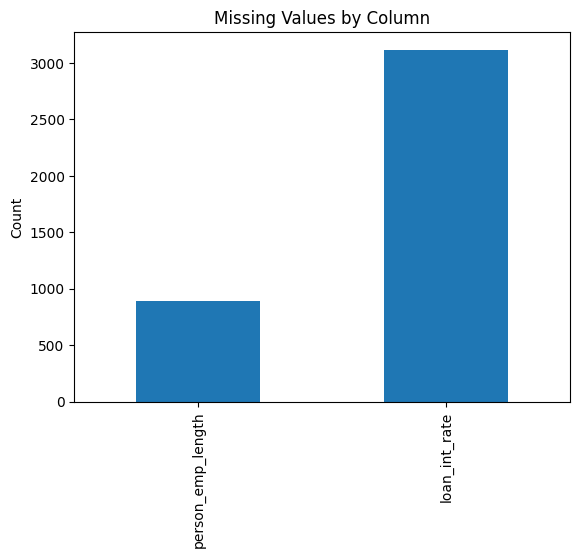

In [38]:
# VISUAL: MISSING VALUES

missing = df.isnull().sum()
missing = missing[missing > 0]

missing.plot(kind='bar')

plt.title('Missing Values by Column')
plt.ylabel('Count')
plt.show()

In [39]:
# Check percentage of missing values

missing_percent = df.isnull().mean() * 100
print(missing_percent)

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.747000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.563856
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64


In [17]:
# Fill missing values with median


df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

# Verify that missing values are gone
print(df.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


# View target variable distribution: Imbalanced

In [13]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [25]:
print("percentage:\n", df['loan_status'].value_counts(normalize=True)*100)

percentage:
 loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


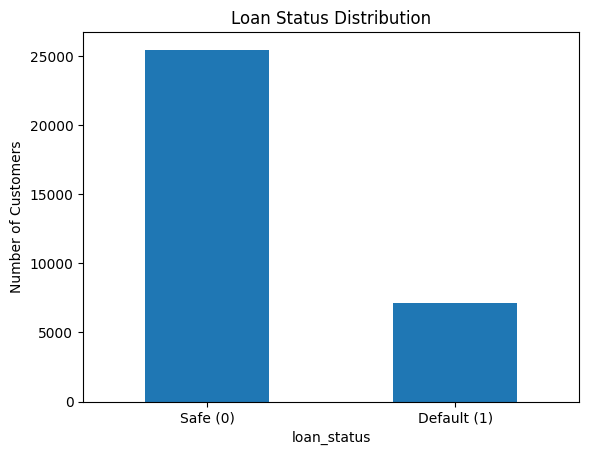

In [34]:
# VISUAL 1: TARGET VARIABLE DISTRIBUTION

import matplotlib.pyplot as plt

df['loan_status'].value_counts().sort_index().plot(
    kind='bar'
)

plt.xticks([0, 1], ['Safe (0)', 'Default (1)'], rotation=0)
plt.title('Loan Status Distribution')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
# VISUAL: DEFAULT RATE BY LOAN GRADE

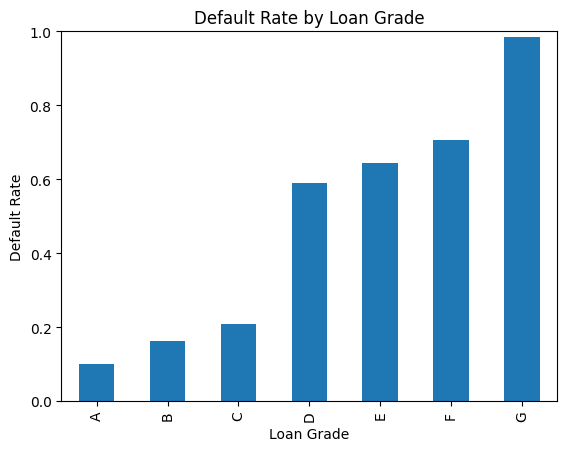

In [41]:
default_by_grade = df.groupby('loan_grade')['loan_status'].mean()

default_by_grade.plot(kind='bar')

plt.title('Default Rate by Loan Grade')
plt.ylabel('Default Rate')
plt.xlabel('Loan Grade')
plt.ylim(0, 1)
plt.show()

# VISUAL: INCOME DISTRIBUTION BY CLASS

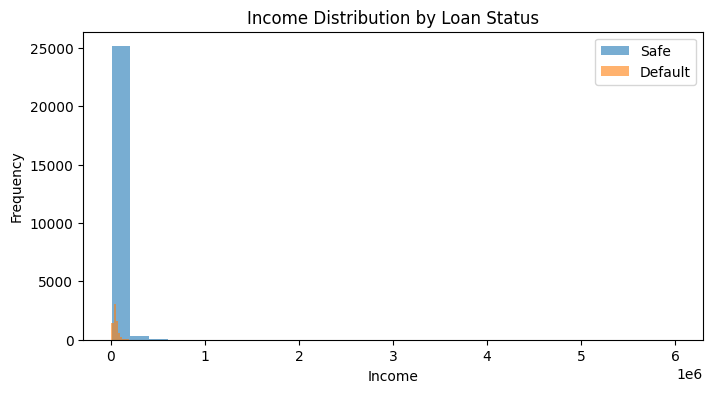

In [42]:
plt.figure(figsize=(8, 4))

plt.hist(
    df[df['loan_status'] == 0]['person_income'],
    bins=30,
    alpha=0.6,
    label='Safe'
)

plt.hist(
    df[df['loan_status'] == 1]['person_income'],
    bins=30,
    alpha=0.6,
    label='Default'
)

plt.legend()
plt.title('Income Distribution by Loan Status')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

# Outliers

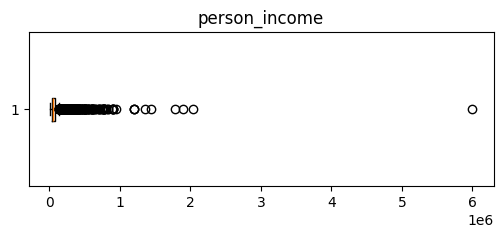

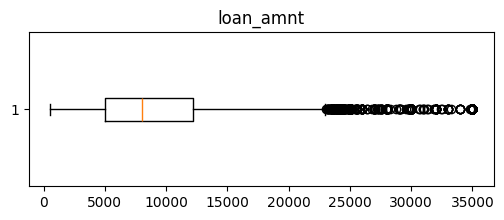

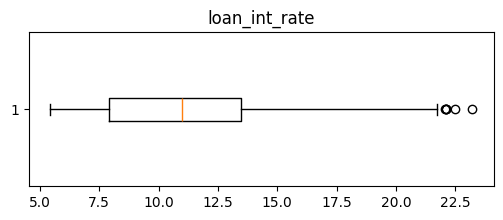

In [52]:
column_outliers = ['person_income', 'loan_amnt', 'loan_int_rate'] 

for col in column_outliers:
    plt.figure(figsize=(6, 2))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(col)
    plt.show()

In [53]:

for col in column_outliers:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

C:\Users\hi\AppData\Local\Temp\ipykernel_17972\3476484604.py:4: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].clip(lower, upper)


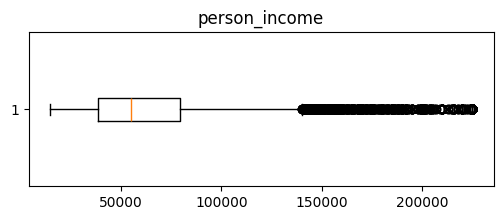

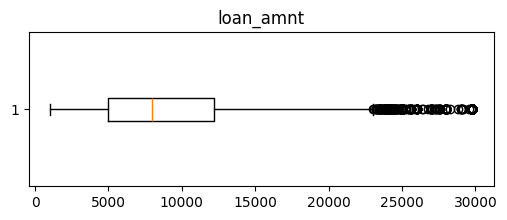

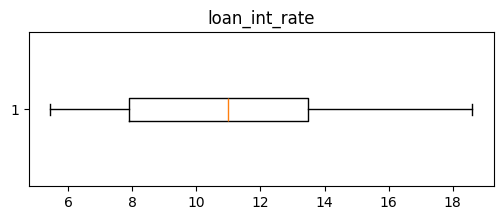

In [54]:
for col in column_outliers:
    plt.figure(figsize=(6, 2))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(col)
    plt.show()

# STEP 2: DEFINE FEATURES (X) AND TARGET (y)


In [18]:
# Target variable
y = df['loan_status']

# Input features (all columns except target)
X = df.drop('loan_status', axis=1)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

# View first few rows
X.head()

Feature matrix shape: (32581, 11)
Target vector shape: (32581,)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,0.55,Y,4


# Identify Numerical and Categorical Columns

In [19]:
# Numerical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical Columns:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


# One-Hot Encode Categorical Variables

Naive Bayes models require numerical input.

So categorical variables must be converted into numbers using **One-Hot Encoding**

In [20]:
# Convert categorical variables to dummy variables
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Shape after encoding:", X_encoded.shape)
X_encoded.head()

Shape after encoding: (32581, 22)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,0.59,3,False,False,True,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0.10,2,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,0.57,3,False,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,0.53,2,False,False,True,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,0.55,4,False,False,True,...,True,False,False,False,True,False,False,False,False,True


In [21]:
X_encoded.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B',
       'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F',
       'loan_grade_G', 'cb_person_default_on_file_Y'],
      dtype='object')

In [22]:
# Check Final Dataset
print("Final feature matrix shape:", X_encoded.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

Final feature matrix shape: (32581, 22)
Target distribution:
loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64


# STEP 6: SPLIT DATA INTO TRAIN AND TEST SETS

In [26]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,      # Feature matrix
    y,              # Target variable
    test_size=0.20, # 20% for testing
    random_state=42,
    stratify=y      # Preserve class proportions
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

Training set shape: (26064, 22)
Testing set shape : (6517, 22)
Training target distribution:
loan_status
0    0.781845
1    0.218155
Name: proportion, dtype: float64


# STEP 7: TRAIN A GAUSSIAN NAIVE BAYES MODEL

### Why Gaussian Naive Bayes?

scikit-learn provides several Naive Bayes models. GaussianNB is ideal here because:

- Dataset contains continuous numerical variables such as income, age, loan amount, and interest rate.
- One-hot encoded categorical variables (0/1 columns) also work fine with GaussianNB

In [28]:

from sklearn.naive_bayes import GaussianNB

# Create model
model = GaussianNB()

# Train model
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


# STEP 8: MAKE PREDICTIONS

In [29]:

# Predicted class labels (0 or 1)
y_pred = model.predict(X_test)

# Predicted probabilities
# [:, 1] gives the probability of class 1 (loan default)
y_prob = model.predict_proba(X_test)[:, 1]

print("First 10 Predictions:")
print(y_pred[:10])

print("\nFirst 10 Probabilities of Default:")
print(y_prob[:10])

First 10 Predictions:
[0 0 0 0 0 0 0 0 0 1]

First 10 Probabilities of Default:
[2.81677589e-01 1.86339951e-01 4.49814640e-04 3.50543053e-01
 3.75070510e-01 2.70642284e-01 2.39006357e-01 1.58755316e-01
 1.63937049e-01 9.24872028e-01]


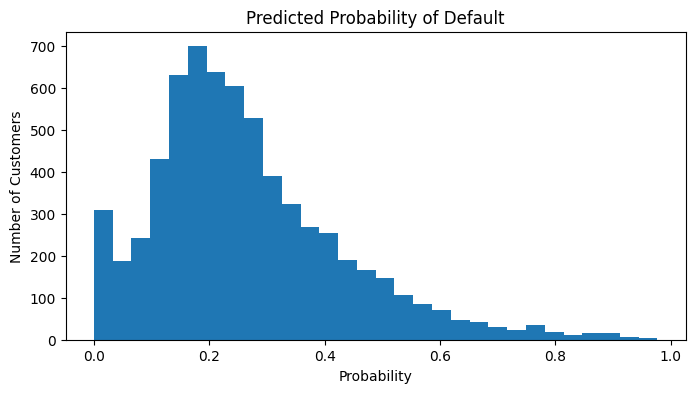

In [44]:
# VISUAL: HISTOGRAM OF PREDICTED PROBABILITIES


plt.figure(figsize=(8, 4))
plt.hist(y_prob, bins=30)

plt.title('Predicted Probability of Default')
plt.xlabel('Probability')
plt.ylabel('Number of Customers')
plt.show()

# STEP 9: MODEL EVALUATION

In [30]:

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC Score
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", round(auc, 4))

Accuracy: 0.8136

Confusion Matrix:
[[4895  200]
 [1015  407]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      5095
           1       0.67      0.29      0.40      1422

    accuracy                           0.81      6517
   macro avg       0.75      0.62      0.65      6517
weighted avg       0.79      0.81      0.78      6517

ROC-AUC Score: 0.7657


## ROC-AUC
```
Measures ranking quality.

Interpretation:

0.50 → random guessing
0.70 → acceptable
0.80 → good
0.90+ → excellent

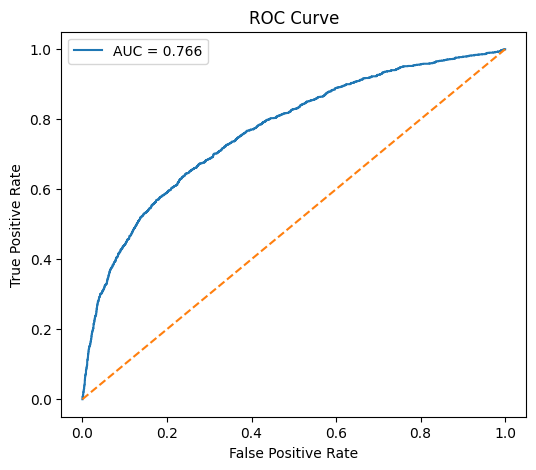

In [43]:
# VISUAL 6: ROC CURVE

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [31]:
# INTERPRET A FEW PREDICTIONS

# Create a comparison table
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability_of_Default": y_prob
})

results.head(10)

,Actual,Predicted,Probability_of_Default
0,0,0,0.281678
1,0,0,0.186340
2,0,0,0.000450
3,0,0,0.350543
4,0,0,0.375071
5,0,0,0.270642
6,0,0,0.239006
7,0,0,0.158755
8,0,0,0.163937
9,1,1,0.924872


# View the Most Risky Customers

In [33]:
results.sort_values(
    by="Probability_of_Default",
    ascending=False
).head(10)

,Actual,Predicted,Probability_of_Default
5037,1,1,0.977057
4985,1,1,0.971208
5300,1,1,0.966606
3555,1,1,0.956509
5702,0,1,0.943807
6387,1,1,0.942124
110,1,1,0.936188
300,1,1,0.935558
3768,1,1,0.933324
9,1,1,0.924872


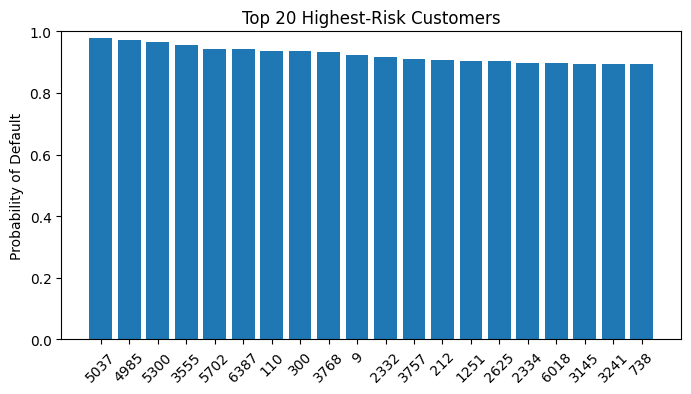

In [49]:
# VISUAL : TOP N HIGHEST RISK CUSTOMERS
N=20

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability_of_Default': y_prob
})

top_N = results.sort_values(
    by='Probability_of_Default',
    ascending=False
).head(N)

plt.figure(figsize=(8, 4))
plt.bar(
    range(len(top_N)),
    top_N['Probability_of_Default']
)

plt.xticks(
    range(len(top_N)),
    top_N.index,
    rotation=45
)

plt.ylim(0, 1)
plt.title(f'Top {N} Highest-Risk Customers')
plt.ylabel('Probability of Default')
plt.show()